In [43]:
# !pip install deepxde
import deepxde as dde
import numpy as np
import torch
import matplotlib.pyplot as plt

In [44]:
def pde(x_t,u):
  u_t = dde.grad.jacobian(u,x_t,i=0,j=1)
  u_xx = dde.grad.hessian(u,x_t,i=0,j=0)
  return u_t - 0.4*u_xx

In [45]:
geom = dde.geometry.Interval(0,1)
timedomain = dde.geometry.TimeDomain(0,1)
geomtime = dde.geometry.GeometryXTime(geom,timedomain)

In [46]:
bc = dde.icbc.DirichletBC(
    geomtime,
    lambda x: 0,
    lambda _, on_boundary: on_boundary
)

ic = dde.icbc.IC(
    geomtime,
    lambda x: np.sin(np.pi*x[:,0:1]),
    lambda _, on_initial: on_initial
)

In [47]:
data = dde.data.TimePDE(geomtime, pde, [bc, ic], num_domain=2000, num_boundary=200, num_initial=200)
net  = dde.nn.FNN([2] + [64]*4 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)


In [ ]:
model.compile("adam", lr=1e-3)
model.train(iterations=10000)

Compiling model...
'compile' took 0.037760 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7aac8bbcbc40>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7aac8bbcbc40>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7aac8bbc9a80>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7aac8bbc9a80>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [1.16e-02, 7.34e-03, 4.08e-01]    [1.16e-02, 7.34e-03, 4.08e-01]    []  
1000      [5.65e-03, 1.61e-03, 3.14e-04]    [5.65e-03, 1.61e-03, 3.14e-04]    []  
2000      [8.82e-05, 3.03e-05, 1.44e-05]    [8.82e-05, 3.03e-05, 1.44e-05]    []  
3000      [4.13e-05, 1.97e-05, 7.86e-06]    [4.13e-05, 1.97e-05, 7.86e-06]    []  
4000      [8.32e-04, 2.98e-04, 1.06e-04]    [8.32e-04, 2.98e-04, 1.06e-04]    []  
5000      [

(<deepxde.model.LossHistory at 0x7aac8bdda0f0>,
 <deepxde.model.TrainState at 0x7aac8d0f2480>)

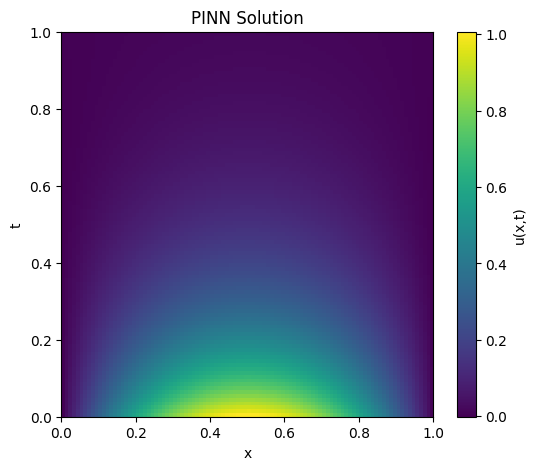

In [19]:
x = np.linspace(0, 1, 100)
t = np.linspace(0, 1, 100)

X, T = np.meshgrid(x, t)

XT = np.hstack((
    X.reshape(-1, 1),
    T.reshape(-1, 1)
))
U = model.predict(XT).reshape(100, 100)
plt.figure(figsize=(6,5))
plt.imshow(U,extent=[0,1,0,1],origin="lower",aspect="auto")
plt.colorbar(label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN Solution")
plt.show()

In [ ]:
def exact_sol(x,t):
  return np.exp(-0.4*(np.pi**2)*t) *np.sin(np.pi*x)


In [ ]:
U_true = exact_sol(X,T)

In [30]:
U_true = U_true.reshape(100,100)

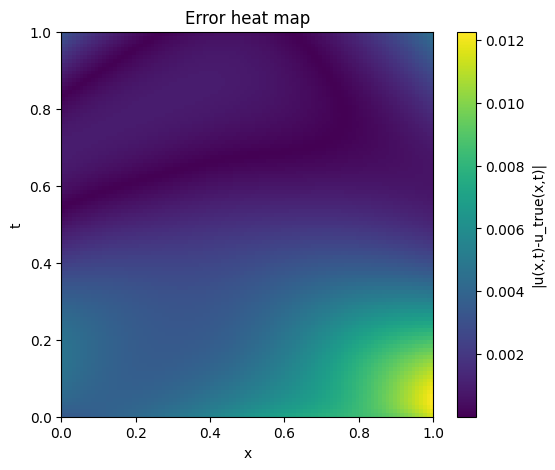

In [20]:
plt.figure(figsize=(6,5))
plt.imshow(abs(U-U_true),extent=[0,1,0,1],origin="lower",aspect="auto")
plt.colorbar(label="|u(x,t)-u_true(x,t)|")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Error heat map")
plt.show()

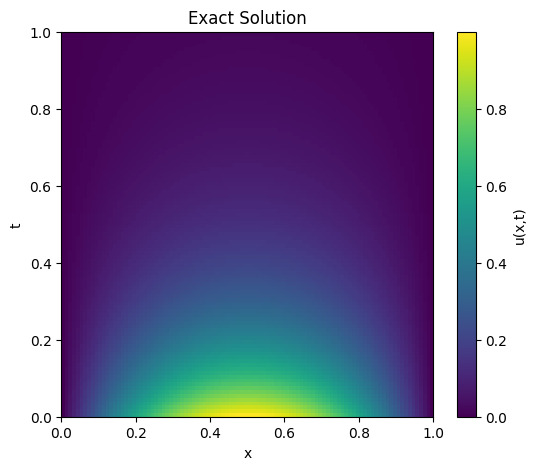

In [21]:
plt.figure(figsize=(6,5))
plt.imshow(U_true,extent=[0,1,0,1],origin="lower",aspect="auto")
plt.colorbar(label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Exact Solution")
plt.show()

In [29]:
L2 = np.linalg.norm((U_true-U))/np.linalg.norm(U_true)
print("L2 error: ", L2)

L2 error:  0.013822143498441034


Compiling model...
'compile' took 0.004611 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [1.11e-02, 7.40e-03, 4.08e-01]    [1.11e-02, 7.40e-03, 4.08e-01]    []  
1000      [4.39e-04, 1.49e-04, 8.02e-05]    [4.39e-04, 1.49e-04, 8.02e-05]    []  
2000      [5.78e-04, 1.39e-04, 6.02e-05]    [5.78e-04, 1.39e-04, 6.02e-05]    []  

Best model at step 1000:
  train loss: 6.69e-04
  test loss: 6.69e-04
  test metric: []

'train' took 44.245081 s

Compiling model...
'compile' took 0.003717 s

Training model...

Step      Train loss                        Test loss                         Test metric
0         [1.14e-02, 6.90e-03, 4.08e-01]    [1.14e-02, 6.90e-03, 4.08e-01]    []  
1000      [4.12e-04, 1.80e-04, 8.08e-05]    [4.12e-04, 1.80e-04, 8.08e-05]    []  
2000      [9.40e-05, 3.79e-05, 1.59e-05]    [9.40e-05, 3.79e-05, 1.59e-05]    []  

Best model at step 2000:
  train loss: 1.48e-04
  test loss: 1.48e-04
  tes

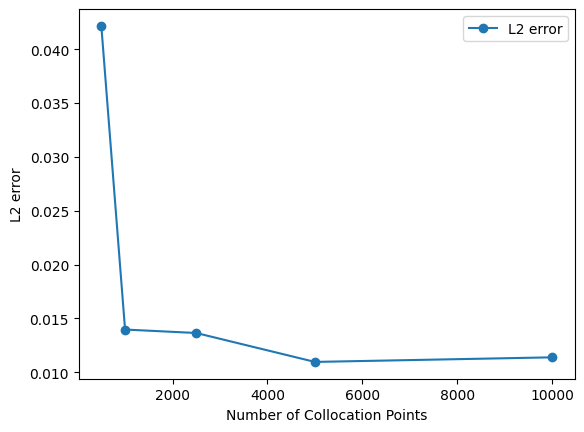

In [51]:
points =[500, 1000, 2500, 5000, 10000]
L2_error = []
for p in points:
  data = dde.data.TimePDE(geomtime, pde, [bc, ic], num_domain=p, num_boundary=200, num_initial=200)
  net  = dde.nn.FNN([2] + [64]*4 + [1], "tanh", "Glorot normal")
  model = dde.Model(data, net)
  model.compile("adam", lr=1e-3)
  model.train(iterations=2000)
  U = model.predict(XT).reshape(100, 100)
  L2 = np.linalg.norm((U_true-U))/np.linalg.norm(U_true)
  L2_error.append(L2)

plt.plot(points, L2_error, marker='o', label="L2 error")
plt.xlabel("Number of Collocation Points")
plt.ylabel("L2 error")
plt.legend()
plt.show()

# observation:
# As no of collocation points increase the model basically has more information(data) about pde throughout the domain.
#So natuarlly performance increase but training becomes slower for 500 collocation points it took model almost 44 seconds but for 10000 it took 331 seconds
# And after slowly the price(computation) to payoff(better model) ratio to increase the points decreases as we increase no of points(diminshing returns).

In [52]:
def wave_pde(x_t,u):
  u_tt = dde.grad.hessian(u,x_t,i=0,j=1)
  u_xx = dde.grad.hessian(u,x_t,i=0,j=0)
  return u_tt - u_xx


In [53]:
geom = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

In [54]:
bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda _, on_boundary: on_boundary)
ic = dde.icbc.IC(geomtime, lambda x: np.sin(np.pi * x[:, 0:1]), lambda _, on_initial: on_initial)
def u_t(x_t,u,_):
  return dde.grad.jacobian(u,x_t,i=0,j=1)
ic_1 =dde.icbc.OperatorBC(
    geomtime,
    u_t,
    lambda _, on_initial: on_initial
)

In [55]:
data = dde.data.TimePDE(geomtime, wave_pde, [bc, ic,ic_1], num_domain=5000, num_boundary=200, num_initial=200)
net  = dde.nn.FNN([2] + [64]*4 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)

model.compile("adam", lr=1e-3)
model.train(iterations=10000)

Compiling model...
'compile' took 0.027677 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7aac58c90b80>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7aac58c90b80>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7aac50e80d60>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7aac50e80d60>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                                  Test loss                                   Test metric
0         [6.55e-03, 6.94e-03, 4.08e-01, 9.06e-03]    [6.55e-03, 6.94e-03, 4.08e-01, 9.06e-03]    []  
1000      [1.19e-03, 1.83e-03, 7.43e-03, 4.50e-03]    [1.19e-03, 1.83e-03, 7.43e-03, 4.50e-03]    []  
2000      [6.79e-03, 7.52e-04, 4.05e-03, 8.59e-03]    [6.79e-03, 7.52e-04, 4.05e-03, 8.59e-03]    []  
3000      [3.74e-04, 5.50e-04, 2.93e-03, 1.20e-03]    [3.74e-04, 5.50e-04, 2.93e-03, 1.20e-03]   

(<deepxde.model.LossHistory at 0x7aac50e9e420>,
 <deepxde.model.TrainState at 0x7aac50e56450>)

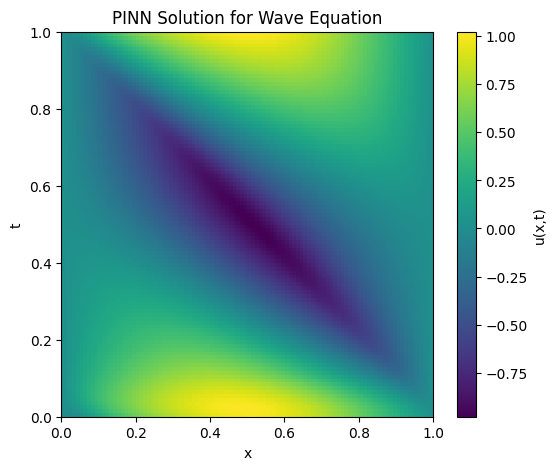

In [56]:
x = np.linspace(0, 1, 100)
t = np.linspace(0, 1, 100)

X, T = np.meshgrid(x, t)

XT = np.hstack((
    X.reshape(-1, 1),
    T.reshape(-1, 1)
))
U = model.predict(XT).reshape(100, 100)
plt.figure(figsize=(6,5))
plt.imshow(U,extent=[0,1,0,1],origin="lower",aspect="auto")
plt.colorbar(label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN Solution for Wave Equation")
plt.show()
# observation:(how it differs from heat equations solution)
# we observe that even with more collocation points(5000) than in heat equation(2000) the model struggles to capture the oscillating solution
# The conclusion is pinn struggles in oscillating regimes and can work better where there is a smooth trend rather than in fast changing trends
# maybe incorporating some additional information about the nature of soln might help pinn to perform better.

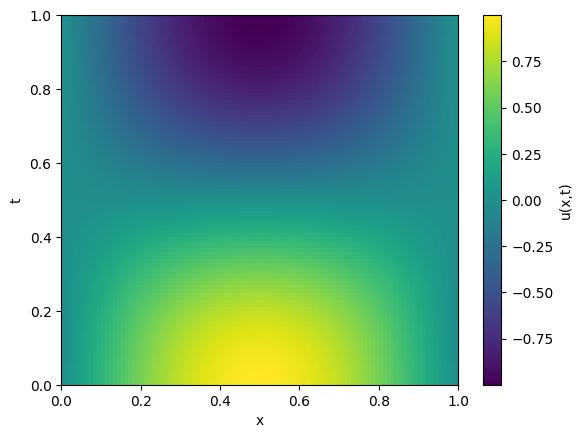

In [37]:
x = np.linspace(0,1,100)
t = np.linspace(0,1,100)

X,T = np.meshgrid(x,t)

#exact soln
U = np.sin(np.pi*X)*np.cos(np.pi*T)

plt.imshow(U,
           extent=[0,1,0,1],
           origin="lower",
           aspect="auto")
plt.colorbar(label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.show()